In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score


# Обработка датасета breast_cancer

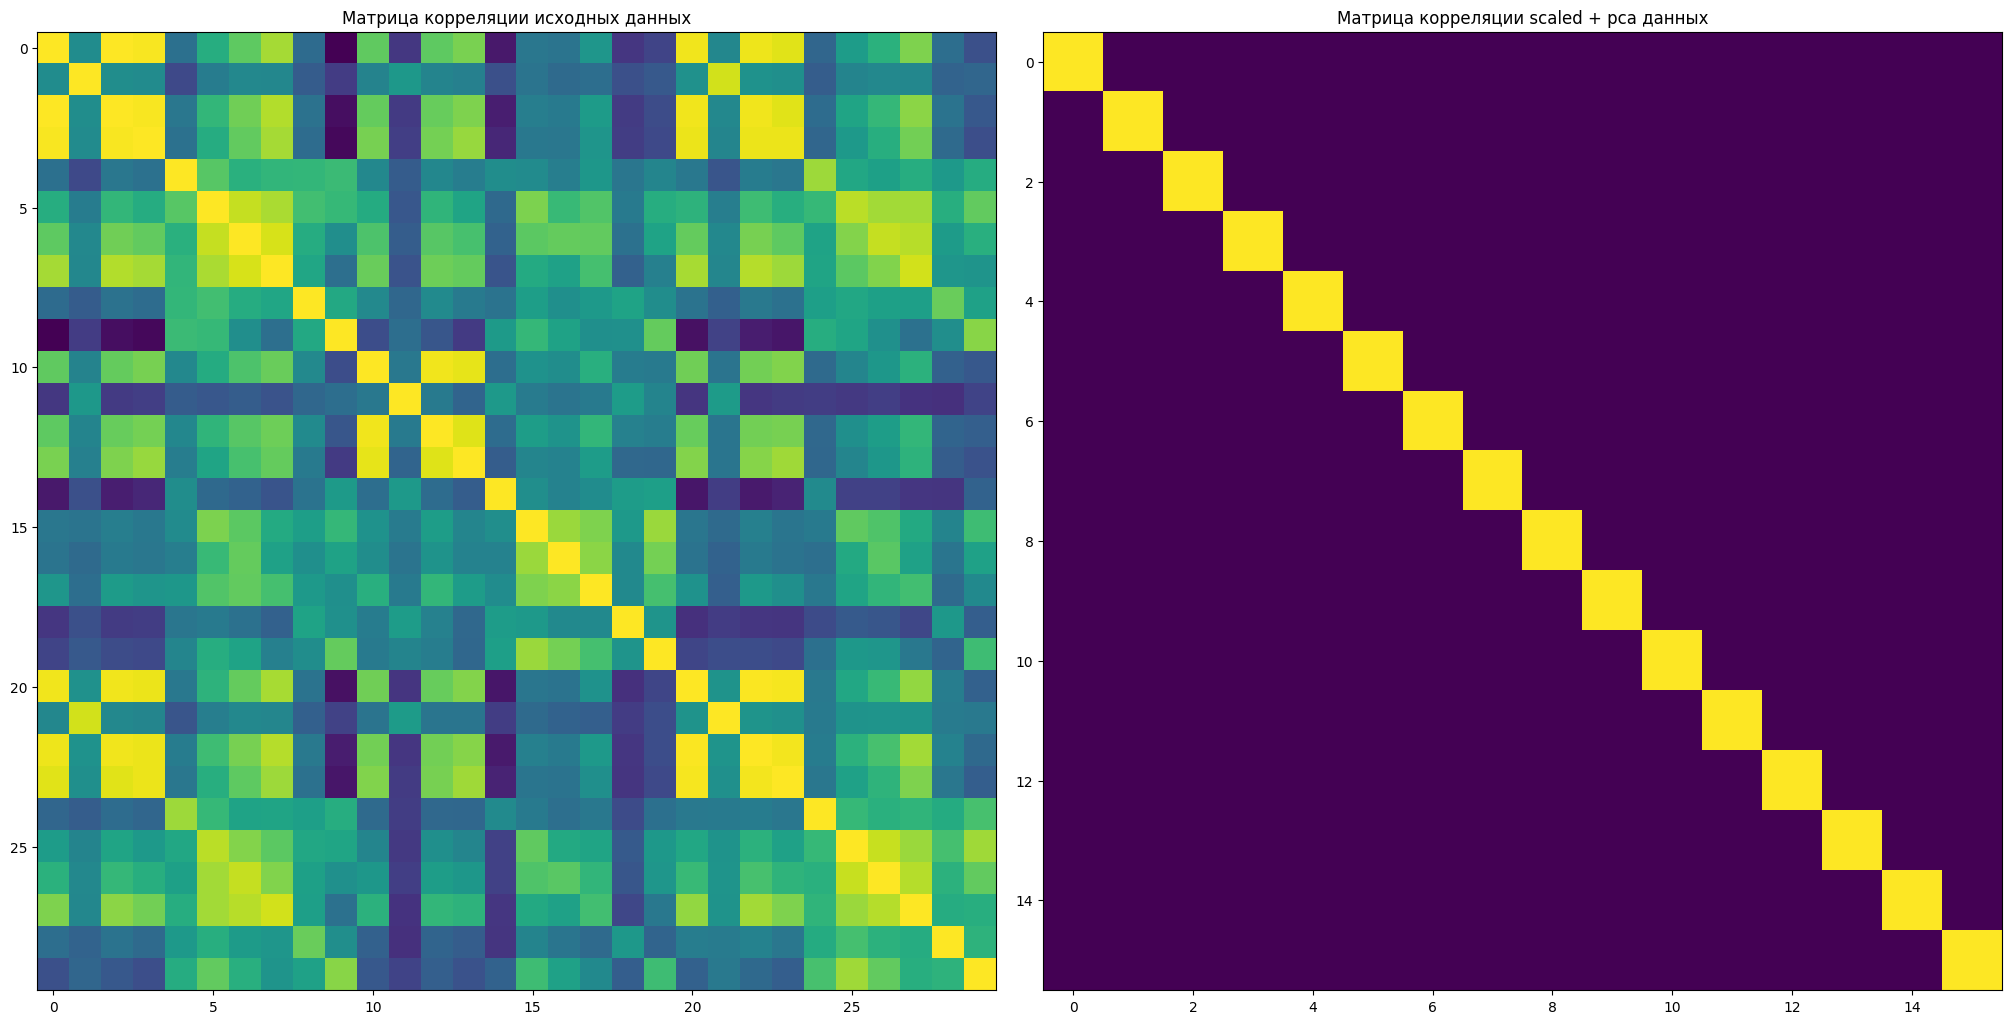

In [5]:
def normalize_features(X):
    # Standardize features to mean=0, std=1
    X_normalized = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    return X_normalized

def clean_up_data(X):
    #for PCA (feature engineering)
    from sklearn.decomposition import PCA

    #for data scaling
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_drop = np.delete(X_scaled, [2, 3, 12, 13, 22, 23], axis=1)
    pca = PCA(n_components=0.99)
    x_pca = pca.fit_transform(X_scaled_drop)

    return x_pca

X = load_breast_cancer(return_X_y=True)[0]
X_norm = clean_up_data(X)
y = load_breast_cancer(return_X_y=True)[1]

s = (len(X_norm) // 5)

X_train = np.array(X_norm[s:])
X_train_with_b = np.c_[X_train, np.ones(X_train.shape[0])]

y_train = np.array(y[s:])
y_train[y_train == 0] = -1

X_test = np.array(X_norm[:s])
X_test_with_b = np.c_[X_test, np.ones(X_test.shape[0])]
y_test = np.array(y[:s])
y_test[y_test == 0] = -1


fig, (ax1, ax2) = plt.subplots(1, 2, layout='constrained', figsize=(20, 10))
ax1.imshow(np.corrcoef(X, rowvar=False))
ax1.set_title('Матрица корреляции исходных данных')
ax2.imshow(np.corrcoef(X_norm, rowvar=False))
ax2.set_title('Матрица корреляции scaled + pca данных')

X_train.shape, y_train.shape, X_test.shape, y_test.shape

plt.show()

# SVM Решение прямой задачи

$y_i(w^Tx_i + b) \ge 1$

$L(w, b) = \dfrac{1}{2}||w||^2_2 + C \sum \max(0, 1 - y_i(w^Tx_i + b))$

вместо отдельного параметра b в $w^Tx + b$ добавим колонку в $w$ и дополним $x$ колонкой из единиц:

$w^Tx + b = w'^Tx'$ where $w' = [b|w], x' = [1|x]$

if $y_i(w^Tx_i) \ge 1$ :

$L(w)' = w$

if $y_i(w^Tx_i) < 1$ :

$L(w)' = w - C\sum y_i x_i$


0.8414889861266164


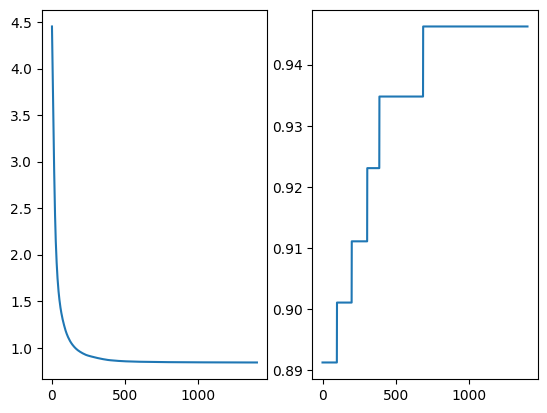

In [12]:
def primal(y, X, w, C, step, iters, tol):
    def accuracy(y, X, w):
        idxs = np.sign(np.dot(X, w))
        res = 0
        for i in range(y.shape[0]):
            if y[i] == idxs[i]:
                res += 1
        return (f1_score(y, idxs), res/y.shape[0])

    hist_H = []
    hist_w = []
    hist_accuracy = []
    w = w.copy()
    for _ in range(iters):
        gradw = w.copy()
        for i in range(X.shape[0]):
            L = y[i] * np.dot(X[i], w)
            if L < 1:
                gradw -= C * X[i] * y[i]
        w -= step * gradw
        margins = y * np.dot(X, w)
        hinge_loss = np.maximum(0, 1 - margins)
        H = 0.5 * np.linalg.norm(w)**2 + C * np.sum(hinge_loss)
        hist_w.append(np.linalg.norm(w))
        hist_H.append(H)
        hist_accuracy.append(accuracy(y_test, X_test_with_b, w)[0])
        if (len(hist_H) > 1 and np.abs(hist_H[-2]-hist_H[-1]) < tol):
            break


    return w, hist_H, hist_w, hist_accuracy

C = 0.01
STEP = 0.001
ITERS = 10000
TOL = 1e-8
w = np.zeros(X_train_with_b.shape[1])
w_star, hist_obj, hist_w, hist_accuracy = primal(y_train, X_train_with_b, w.copy(), C, STEP, ITERS, TOL)

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(hist_obj)
ax2.plot(hist_accuracy)
print(hist_obj[-1])
plt.show()

# SVM Решение Двойственной задачи


$L(a) = \max \sum a_i - \dfrac{1}{2} \sum_i \sum_j y_i y_j a_i a_j <x_i, x_j> $

s.t.:

$\sum y_i a_i = 0$

$0 \le a_i \le C$

$L'(a) =  1- a_i y_i y_j <x_i, x_j>$

Для учета ограничения $\sum y_i a_i = 0$ рассмотрим 2 способа:
1. метод пенальти, за выход из $\sum y_i a_i = 0$ накладываем штраф. Тогда

$L(a) = \max \sum a_i - \dfrac{1}{2} \sum_i \sum_j y_i y_j a_i a_j <x_i, x_j> - 100 * ||y a||^2$

$\nabla L(a) = 1 - a_i y_i y_j <x_i, x_j> - 100 * 2 * y * ||y a||$

2. метод проекции на $\sum y_i a_i = 0$

# Ускоренный метод Нестерова и Обычный градиентный спуск. Проекция.



Данный алгоритм является разновидностью метода последовательных проекций на множества:

1. $\mathcal{B} = \{\alpha \in \mathbb{R}^n \mid 0 \leq \alpha_i \leq C\}$ - гиперкуб
2. $\mathcal{H} = \{\alpha \in \mathbb{R}^n \mid \sum \alpha_i y_i = 0\}$ - гиперплоскость

Алгоритм последовательно проецирует на $\mathcal{B}$ и $\mathcal{H}$, сходясь к проекции на их пересечение $\mathcal{F} = \mathcal{B} \cap \mathcal{H}$.


Training Nesterov...
Training Standard GD...

Comparison Results (Linear Kernel):
Nesterov - F1: 0.9213, Accuracy: 0.9381
Standard GD - F1: 0.9333, Accuracy: 0.9469
Nesterov converged in 5000 iterations
Standard GD converged in 5000 iterations


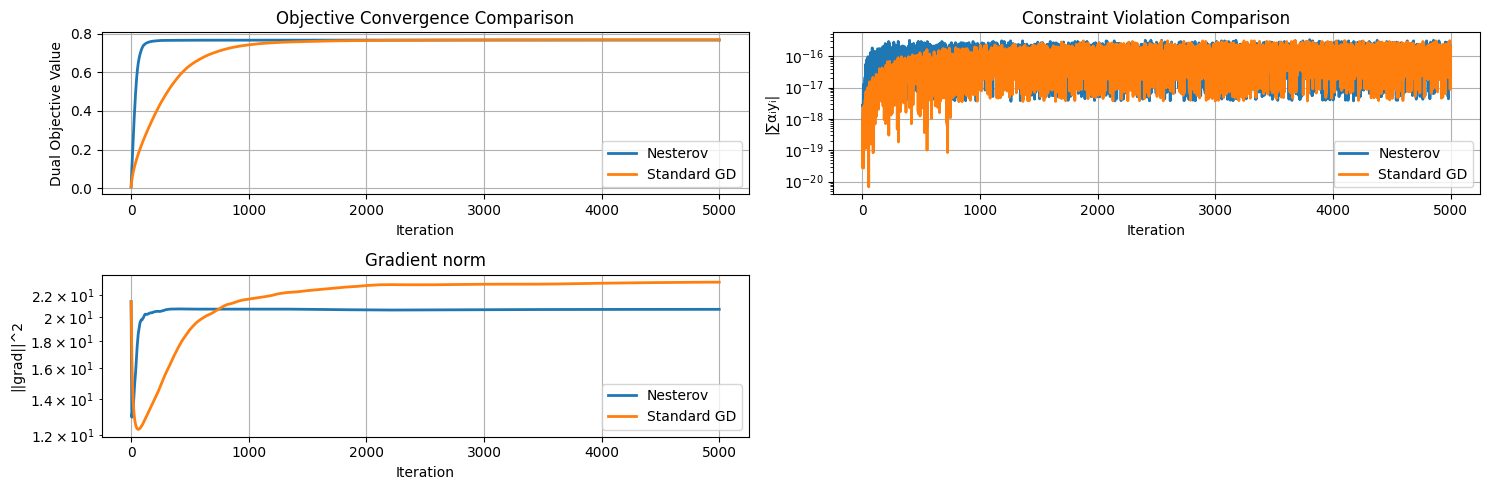

In [11]:


def dual_accuracy(a):
    def inner_acc(y, X, w):
        idxs = np.sign(np.dot(X, w))
        if (0 in idxs):
            return (0, 0)
        res = 0
        for i in range(y.shape[0]):
            if y[i] == idxs[i]:
                res += 1
        # print(idxs[:10], y[:20], y[-20:], y.shape, X.shape, w.shape, idxs.shape, res)
        return (f1_score(y, idxs), res/y.shape[0])
    w_dual = np.sum(a[:, np.newaxis] * y_train[:, np.newaxis] * X_train, axis=0)
    return inner_acc(y_test, X_test, w_dual)

class ProjectionGD:
    def compute_kernel_matrix(self, X):
        """Compute linear kernel matrix: K_ij = x_i · x_j"""
        return X @ X.T
    
    def compute_gradient(self, alpha, K, y):
        """Gradient of dual SVM objective: ∇L(α) = 1 - (K ⊙ yyᵀ)α"""
        Y = np.diag(y)  # Create diagonal matrix from y
        return np.ones(len(y)) - Y @ K @ Y @ alpha
    
    def compute_objective(self, alpha, K, y):
        """Dual objective: L(α) = ∑αᵢ - ½ αᵀ(K ⊙ yyᵀ)α (MAXIMIZATION)"""
        return np.sum(alpha) - 0.5 * alpha.T @ ((K * np.outer(y, y)) @ alpha)


    def simple_project_to_constraints(self, alpha, y):
        a = np.clip(alpha.copy(), 0, self.C)
        scalar = np.dot(y, a) / np.dot(y, y)

        res = a - scalar * y
        return res

    def project_to_constraints(self, alpha, y):
        """More robust projection"""
        n = len(alpha)
        alpha = np.clip(alpha, 0, self.C)
        sum_alpha_y = np.dot(alpha, y)
        
        if abs(sum_alpha_y) < 1e-12:
            return alpha
        
        # Use iterative projection for better numerical stability
        max_proj_iter = 100
        alpha_proj = alpha.copy()
        
        for proj_iter in range(max_proj_iter):
            sum_violation = np.dot(alpha_proj, y)
            if abs(sum_violation) < 1e-12:
                break
                
            # Find the most adjustable variables
            if sum_violation > 0:
                can_decrease = (y > 0) & (alpha_proj > 0)
                can_increase = (y < 0) & (alpha_proj < self.C)
            else:
                can_increase = (y > 0) & (alpha_proj < self.C)
                can_decrease = (y < 0) & (alpha_proj > 0)
            
            total_capacity = (np.sum(can_decrease * np.abs(y)) + 
                            np.sum(can_increase * np.abs(y)))
            
            if total_capacity < 1e-12:
                break
                
            adjustment = sum_violation / total_capacity
            
            if sum_violation > 0:
                alpha_proj[can_decrease] -= adjustment * y[can_decrease]
                alpha_proj[can_increase] -= adjustment * y[can_increase]
            else:
                alpha_proj[can_increase] -= adjustment * y[can_increase]
                alpha_proj[can_decrease] -= adjustment * y[can_decrease]
            
            alpha_proj = np.clip(alpha_proj, 0, self.C)
        
        return alpha_proj

class LinearNesterovDualSVM(ProjectionGD):
    def __init__(self, C=1.0, max_iter=1000, learning_rate=0.01, momentum=0.9, tol=1e-4):
        self.C = C
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.tol = tol
        
        self.alpha = None
        self.support_vectors_ = None
        self.support_vector_labels_ = None
        self.X_train = None
        self.y_train = None

        self.grad_history = []

    def fit(self, X, y):
        """Fit linear SVM using Nesterov accelerated gradient"""
        # Ensure labels are ±1
        y = np.where(y == 0, -1, y)
        
        self.X_train = X.copy()
        self.y_train = y.copy()
        
        n_samples = X.shape[0]
        K = self.compute_kernel_matrix(X)
        
        # Initialize
        alpha = np.zeros(n_samples)
        v = np.zeros(n_samples)  # velocity term
        
        objective_history = []
        constraint_violation_history = []

        for iteration in range(self.max_iter):
            # Nesterov lookahead
            alpha_lookahead = alpha + self.momentum * v
            
            # Compute gradient at lookahead position
            grad = self.compute_gradient(alpha_lookahead, K, y)

            self.grad_history.append(np.linalg.norm(grad))
            # Update velocity and parameters
            v = self.momentum * v + self.learning_rate * grad
            alpha_new = alpha + v
            
            # Project to constraints
            alpha_new = self.simple_project_to_constraints(alpha_new, y)
            
            # Track convergence metrics
            obj_val = self.compute_objective(alpha_new, K, y)
            objective_history.append(obj_val)
            
            constraint_violation = abs(np.dot(alpha_new, y))
            constraint_violation_history.append(constraint_violation)
            
            # Check convergence
            if iteration > 10:
                if np.linalg.norm(grad) < self.tol:
                    break
            
            alpha = alpha_new
        
        self.alpha = alpha
        
        # Store support vectors
        sv_indices = self.alpha > 1e-5
        self.support_vectors_ = X[sv_indices]
        self.support_vector_labels_ = y[sv_indices]
        self.alpha_sv = self.alpha[sv_indices]
        
        return objective_history, constraint_violation_history

class StandardGradientDescentDualSVM(ProjectionGD):
    """Standard Gradient Descent for comparison"""
    def __init__(self, C=1.0, max_iter=1000, learning_rate=0.01, tol=1e-4):
        self.C = C
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.tol = tol
        
        self.alpha = None
        self.support_vectors_ = None
        self.support_vector_labels_ = None
        self.X_train = None
        self.y_train = None

        self.grad_history = []

    def fit(self, X, y):
        y = np.where(y == 0, -1, y)
        self.X_train = X.copy()
        self.y_train = y.copy()
        
        n_samples = X.shape[0]
        K = self.compute_kernel_matrix(X)
        
        alpha = np.zeros(n_samples)
        objective_history = []
        constraint_violation_history = []
        
        for iteration in range(self.max_iter):
            # Standard gradient update (no momentum)
            grad = self.compute_gradient(alpha, K, y)
            self.grad_history.append(np.linalg.norm(grad))
            alpha_new = alpha + self.learning_rate * grad
            alpha_new = self.simple_project_to_constraints(alpha_new, y)
            
            # Track metrics
            obj_val = self.compute_objective(alpha_new, K, y)
            objective_history.append(obj_val)
            
            constraint_violation = abs(np.dot(alpha_new, y))
            constraint_violation_history.append(constraint_violation)
            
            # Check convergence
            if iteration > 10:
                if np.linalg.norm(grad) < self.tol:
                    break
            
            alpha = alpha_new
        
        self.alpha = alpha
        
        # Store support vectors
        sv_indices = self.alpha > 1e-5
        self.support_vectors_ = X[sv_indices]
        self.support_vector_labels_ = y[sv_indices]
        self.alpha_sv = self.alpha[sv_indices]
        
        return objective_history, constraint_violation_history

# Demonstration functions using your existing data
def demonstrate_linear_svm():
    """Demonstrate Linear Dual SVM with Nesterov acceleration using your data"""
    
    print("Training Linear Dual SVM with Nesterov Acceleration...")
    svm = LinearNesterovDualSVM(C=0.1, max_iter=1000, learning_rate=0.0001, momentum=0.9)
    objective_history, constraint_history = svm.fit(X_train, y_train)
    
    # Evaluate using your dual_accuracy function
    f1_score, accuracy = dual_accuracy(svm.alpha)
    
    print(f"Test F1 Score: {f1_score:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Number of support vectors: {len(svm.support_vectors_)}")
    print(f"Final constraint violation: {constraint_history[-1]:.2e}")
    
    # Plot results
    plt.figure(figsize=(15, 5))
    
    # Plot convergence
    plt.subplot(1, 3, 1)
    plt.plot(objective_history)
    plt.title('Nesterov: Objective Convergence')
    plt.xlabel('Iteration')
    plt.ylabel('Dual Objective Value')
    plt.grid(True)
    
    # Plot constraint violation
    plt.subplot(1, 3, 2)
    plt.semilogy(constraint_history)
    plt.title('Nesterov: Constraint Violation')
    plt.xlabel('Iteration')
    plt.ylabel('|∑αᵢyᵢ|')
    plt.grid(True)
    
    return svm, f1_score, accuracy

def compare_linear_methods(nesterov_svm, standard_svm):
    """Compare Nesterov vs Standard GD for linear SVM using your data"""
    
    # Nesterov acceleration
    print("Training Nesterov...")
    nesterov_obj, nesterov_constraint = nesterov_svm.fit(X_train, y_train)
    
    # Standard gradient descent
    print("Training Standard GD...")
    standard_obj, standard_constraint = standard_svm.fit(X_train, y_train)
    
    # Compare performance using your dual_accuracy function
    nesterov_f1, nesterov_acc = dual_accuracy(nesterov_svm.alpha)
    standard_f1, standard_acc = dual_accuracy(standard_svm.alpha)
    
    print(f"\nComparison Results (Linear Kernel):")
    print(f"Nesterov - F1: {nesterov_f1:.4f}, Accuracy: {nesterov_acc:.4f}")
    print(f"Standard GD - F1: {standard_f1:.4f}, Accuracy: {standard_acc:.4f}")
    print(f"Nesterov converged in {len(nesterov_obj)} iterations")
    print(f"Standard GD converged in {len(standard_obj)} iterations")
    
    # Plot convergence comparison
    plt.figure(figsize=(15, 5))
    
    plt.subplot(2, 2, 1)
    plt.plot(nesterov_obj, label='Nesterov', linewidth=2)
    plt.plot(standard_obj, label='Standard GD', linewidth=2)
    plt.title('Objective Convergence Comparison')
    plt.xlabel('Iteration')
    plt.ylabel('Dual Objective Value')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(2, 2, 2)
    plt.semilogy(nesterov_constraint, label='Nesterov', linewidth=2)
    plt.semilogy(standard_constraint, label='Standard GD', linewidth=2)
    plt.title('Constraint Violation Comparison')
    plt.xlabel('Iteration')
    plt.ylabel('|∑αᵢyᵢ|')
    plt.legend()
    plt.grid(True)
    
    # Plot support vectors comparison
    # plt.subplot(2, 3, 3)
    # methods = ['Nesterov', 'Standard GD']
    # sv_counts = [len(nesterov_svm.support_vectors_), len(standard_svm.support_vectors_)]
    # plt.bar(methods, sv_counts)
    # plt.title('Number of Support Vectors')
    # plt.ylabel('Count')

    plt.subplot(2, 2, 3)
    plt.semilogy(nesterov_svm.grad_history, label='Nesterov', linewidth=2)
    plt.semilogy(standard_svm.grad_history, label='Standard GD', linewidth=2)
    plt.title('Gradient norm')
    plt.xlabel('Iteration')
    plt.ylabel('||grad||^2')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return nesterov_svm, standard_svm

def tune_linear_svm_nesterov():
    """Simple hyperparameter tuning for linear SVM using your data"""
    
    best_f1 = 0
    best_accuracy = 0
    best_params = {}
    
    # Grid search over C and learning rate
    for C in [0.01, 0.1, 1.0, 10.0]:
        for lr in [1e-6, 1e-5, 1e-4, 1e-3]:
            # print(f"Testing C={C}, lr={lr}")
            svm = LinearNesterovDualSVM(C=C, learning_rate=lr, momentum=0.9, max_iter=500, tol=1e-8)
            svm.fit(X_train, y_train)
            f1_score, accuracy = dual_accuracy(svm.alpha)
            
            if f1_score > best_f1:
                best_f1 = f1_score
                best_accuracy = accuracy
                best_params = {'C': C, 'learning_rate': lr}
    
    print(f"\nHyperparameter Tuning Results:")
    print(f"Best F1 Score: {best_f1:.4f}")
    print(f"Best Accuracy: {best_accuracy:.4f}")
    print(f"Best Parameters: {best_params}")
    
    return best_f1, best_accuracy, best_params

def tune_linear_svm_std():
    """Simple hyperparameter tuning for linear SVM using your data"""
    
    best_f1 = 0
    best_accuracy = 0
    best_params = {}
    
    # Grid search over C and learning rate
    for C in [0.01, 0.1, 1.0, 10.0]:
        for lr in [1e-5, 1e-4, 1e-3]:
            # print(f"Testing C={C}, lr={lr}")
            svm = StandardGradientDescentDualSVM(C=C, learning_rate=lr, max_iter=500, tol=1e-8)
            svm.fit(X_train, y_train)
            f1_score, accuracy = dual_accuracy(svm.alpha)
            
            if f1_score > best_f1:
                best_f1 = f1_score
                best_accuracy = accuracy
                best_params = {'C': C, 'learning_rate': lr}
    
    print(f"\nHyperparameter Tuning Results:")
    print(f"Best F1 Score: {best_f1:.4f}")
    print(f"Best Accuracy: {best_accuracy:.4f}")
    print(f"Best Parameters: {best_params}")
    
    return best_f1, best_accuracy, best_params

# print("=" * 60)
# svm, f1, acc = demonstrate_linear_svm()

print("=" * 60)
compare_linear_methods(
    LinearNesterovDualSVM(C=0.01, max_iter=5000, learning_rate=0.00002, momentum=0.9),
    StandardGradientDescentDualSVM(C=0.01, max_iter=5000, learning_rate=0.00002)
)

print("=" * 60)
# best_f1, best_acc, best_params = tune_linear_svm_nesterov()
# best_f1, best_acc, best_params = tune_linear_svm_std()

# Ускоренный метод Нестерова и Обычный градиентный спуск. Штрафы.

Training Nesterov...
Training Standard GD...

Comparison Results (Linear Kernel):
Nesterov - F1: 0.9333, Accuracy: 0.9469
Standard GD - F1: 0.9333, Accuracy: 0.9469
Nesterov converged in 3000 iterations
Standard GD converged in 3000 iterations


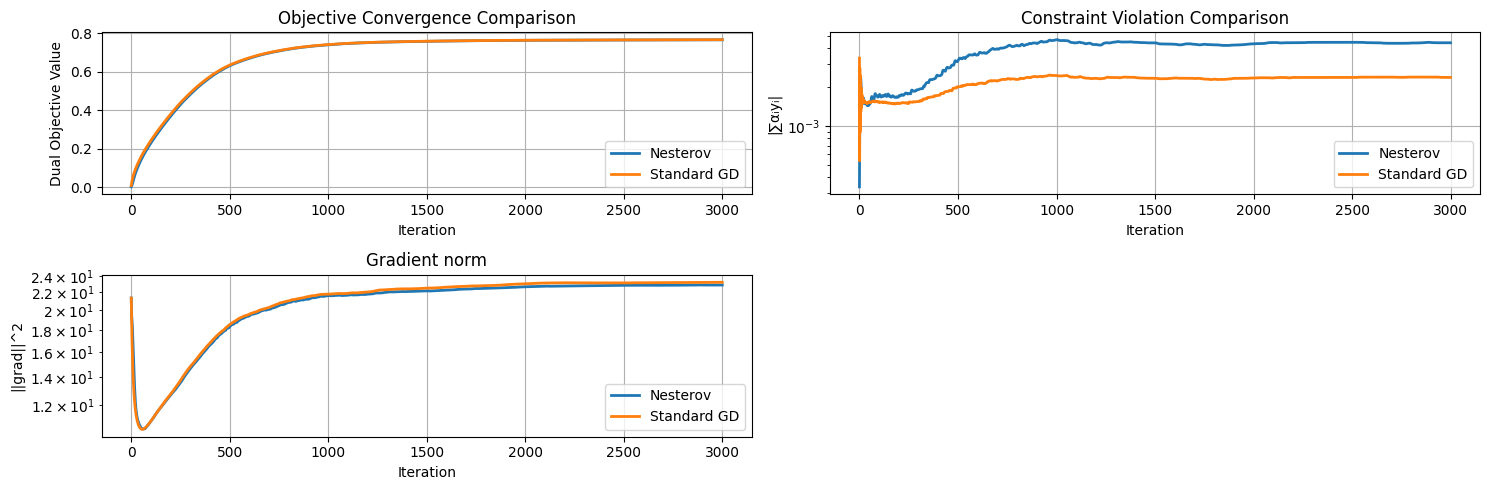

(<__main__.NesterovPenalty at 0x2a0ba06e0>,
 <__main__.StandardGDPenalty at 0x2a0ba0830>)

In [17]:
class PenaltyGD:
    def compute_kernel_matrix(self, X):
        """Compute linear kernel matrix: K_ij = x_i · x_j"""
        return X @ X.T
    
    def compute_gradient(self, alpha, K, y):
        Y = np.diag(y)  # Create diagonal matrix from y
        return np.ones(len(y)) - Y @ K @ Y @ alpha - 200 * y * np.dot(y, alpha)
    
    def compute_objective(self, alpha, K, y):
        """Dual objective (MAXIMIZATION)"""
        return np.sum(alpha) - 0.5 * alpha.T @ ((K * np.outer(y, y)) @ alpha) - 100 * np.dot(y, alpha)**2

class NesterovPenalty(PenaltyGD):
    def __init__(self, C=1.0, max_iter=1000, learning_rate=0.01, momentum=0.9, tol=1e-4):
        self.C = C
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.tol = tol
        
        self.alpha = None
        self.support_vectors_ = None
        self.support_vector_labels_ = None
        self.X_train = None
        self.y_train = None

        self.grad_history = []

    def fit(self, X, y):
        """Fit linear SVM using Nesterov accelerated gradient"""
        # Ensure labels are ±1
        y = np.where(y == 0, -1, y)
        
        self.X_train = X.copy()
        self.y_train = y.copy()
        
        n_samples = X.shape[0]
        K = self.compute_kernel_matrix(X)
        
        # Initialize
        alpha = np.zeros(n_samples)
        v = np.zeros(n_samples)  # velocity term
        
        objective_history = []
        constraint_violation_history = []

        for iteration in range(self.max_iter):
            # Nesterov lookahead
            alpha_lookahead = alpha + self.momentum * v
            
            # Compute gradient at lookahead position
            grad = self.compute_gradient(alpha_lookahead, K, y)

            self.grad_history.append(np.linalg.norm(grad))
            # Update velocity and parameters
            v = self.momentum * v + self.learning_rate * grad
            alpha_new = alpha + v

            # need to enforce box constraints [0, C]
            alpha_new = np.clip(alpha_new, 0, self.C)
            # Track convergence metrics
            obj_val = self.compute_objective(alpha_new, K, y)
            objective_history.append(obj_val)
            
            constraint_violation = abs(np.dot(alpha_new, y))
            constraint_violation_history.append(constraint_violation)
            
            # Check convergence
            if iteration > 10:
                # rel_change = abs(objective_history[-1] - objective_history[-2])
                # if rel_change < self.tol and constraint_violation < 1e-6:
                #     # print(f"Converged after {iteration} iterations")
                #     break
                if np.linalg.norm(grad) < self.tol:
                    break
            
            alpha = alpha_new
        
        self.alpha = alpha
        
        # Store support vectors
        sv_indices = self.alpha > 1e-5
        self.support_vectors_ = X[sv_indices]
        self.support_vector_labels_ = y[sv_indices]
        self.alpha_sv = self.alpha[sv_indices]
        
        return objective_history, constraint_violation_history

class StandardGDPenalty(PenaltyGD):
    """Standard Gradient Descent for comparison"""
    def __init__(self, C=1.0, max_iter=1000, learning_rate=0.01, tol=1e-4):
        self.C = C
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.tol = tol
        
        self.alpha = None
        self.support_vectors_ = None
        self.support_vector_labels_ = None
        self.X_train = None
        self.y_train = None

        self.grad_history = []

    def fit(self, X, y):
        y = np.where(y == 0, -1, y)
        self.X_train = X.copy()
        self.y_train = y.copy()
        
        n_samples = X.shape[0]
        K = self.compute_kernel_matrix(X)
        
        alpha = np.zeros(n_samples)
        objective_history = []
        constraint_violation_history = []
        
        for iteration in range(self.max_iter):
            # Standard gradient update (no momentum)
            grad = self.compute_gradient(alpha, K, y)
            self.grad_history.append(np.linalg.norm(grad))
            alpha_new = alpha + self.learning_rate * grad
            # need to enforce box constraints [0, C]
            alpha_new = np.clip(alpha_new, 0, self.C)
            
            # Track metrics
            obj_val = self.compute_objective(alpha_new, K, y)
            objective_history.append(obj_val)
            
            constraint_violation = abs(np.dot(alpha_new, y))
            constraint_violation_history.append(constraint_violation)
            
            # Check convergence
            if iteration > 10:
                # rel_change = abs(objective_history[-1] - objective_history[-2])
                # if rel_change < self.tol and constraint_violation < 1e-6:
                #     # print(f"Converged after {iteration} iterations")
                #     break
                if np.linalg.norm(grad) < self.tol:
                    break
            
            alpha = alpha_new
        
        self.alpha = alpha
        
        # Store support vectors
        sv_indices = self.alpha > 1e-5
        self.support_vectors_ = X[sv_indices]
        self.support_vector_labels_ = y[sv_indices]
        self.alpha_sv = self.alpha[sv_indices]
        
        return objective_history, constraint_violation_history

compare_linear_methods(
    NesterovPenalty(C=0.01, max_iter=3000, learning_rate=0.000002, momentum=0.9),
    StandardGDPenalty(C=0.01, max_iter=3000, learning_rate=0.00002)
)

# Сравнение двойственного метода и прямого

Running Primal SVM...
Running Dual SVM (Nesterov)...
PRIMAL vs DUAL SVM COMPARISON

1. WEIGHT VECTOR COMPARISON:
Primal ||w||: 0.782808
Dual   ||w||: 0.856759
Weight vector cosine similarity: 0.916572

2. OBJECTIVE VALUE COMPARISON:
Primal objective: 0.843616
Dual objective:   0.744140
Duality gap:      0.099475

3. PREDICTION PERFORMANCE:
Training accuracy - Primal: 0.9803, Dual: 0.9715
Test accuracy     - Primal: 0.9558, Dual: 0.9381

4. SUPPORT VECTORS:
Primal SV count: 121
Dual SV count:   205
Support vector overlap: 105 points

5. KKT CONDITIONS CHECK (Dual):
Stationarity violation: 0.00e+00
Complementary slackness violation: 2.71e+02

6. CONSTRAINT SATISFACTION:
Dual constraint ∑αᵢyᵢ = 0 violation: 9.66e-17
Box constraint violations: 0


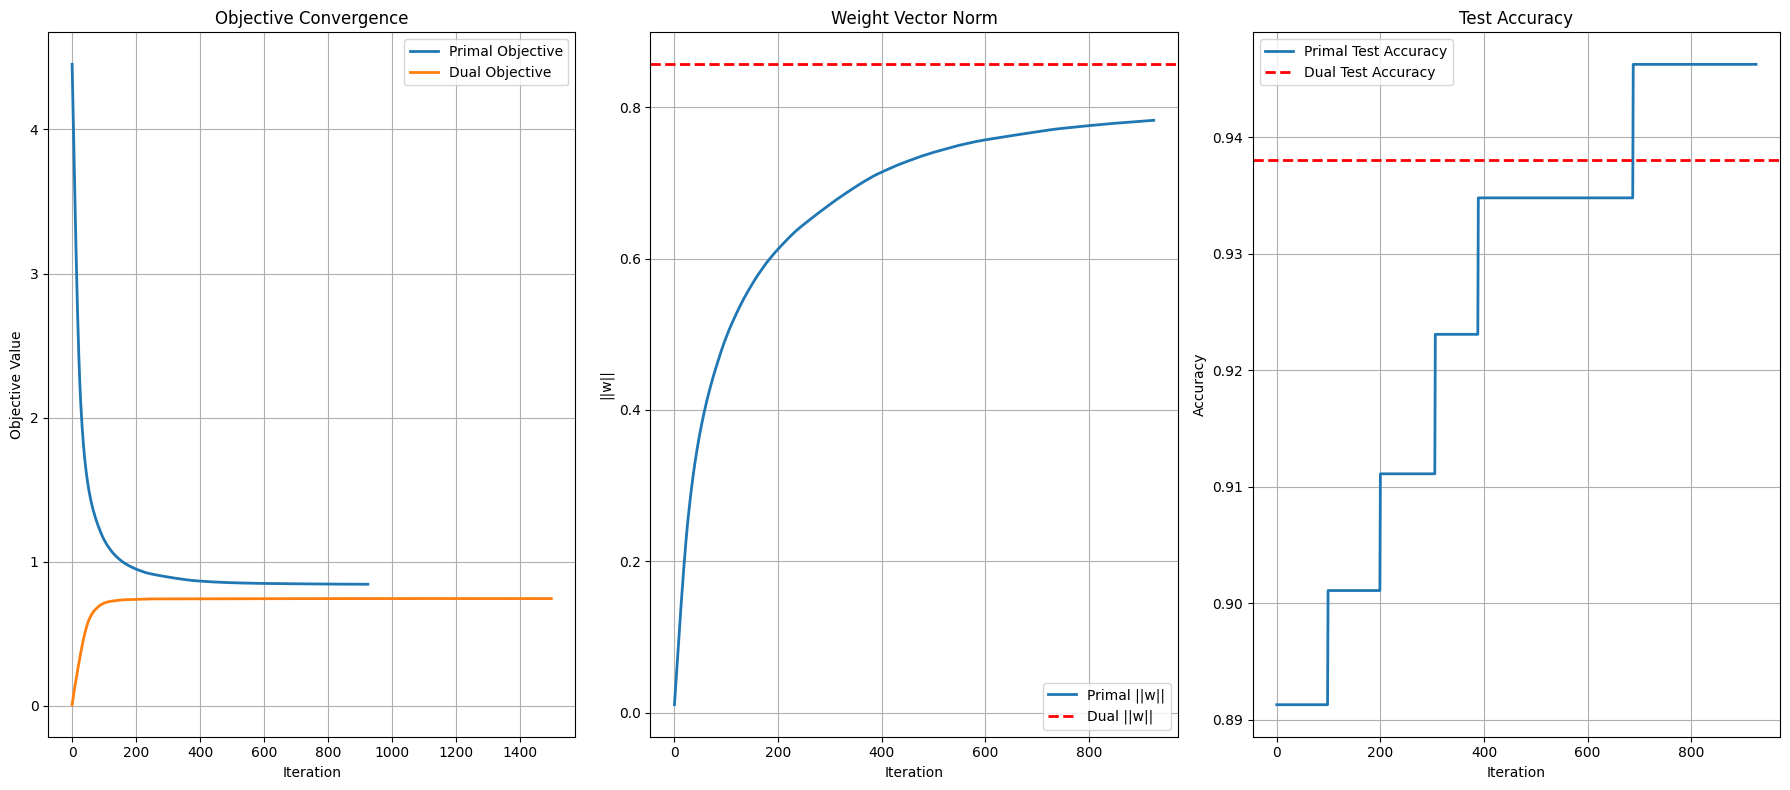


SOLUTION QUALITY ASSESSMENT
Duality Gap                 0.099475 ✓ PASS
Weight Cosine Similarity    0.916572 ✗ FAIL
Accuracy Difference         0.017699 ✓ PASS

Overall Quality: ✗ NEEDS IMPROVEMENT


In [20]:
def compare_primal_dual(primal_solution, dual_solution, X_train, y_train, X_test, y_test, C):
    """
    Comprehensive comparison between primal and dual SVM solutions
    
    Parameters:
    -----------
    primal_solution : tuple (w, hist_H, hist_w, hist_accuracy)
    dual_solution : object with alpha, support_vectors_, etc.
    X_train, y_train : training data
    X_test, y_test : test data
    C : regularization parameter
    """

    def accuracy(y, X, w):
        """Your accuracy function"""
        predictions = np.sign(X @ w)
        return accuracy_score(y, predictions)

    
    w_primal, hist_H, hist_w, hist_accuracy_primal = primal_solution
    alpha_dual = dual_solution.alpha
    
    # Reconstruct w from dual solution
    w_dual = np.sum(alpha_dual[:, np.newaxis] * y_train[:, np.newaxis] * X_train, axis=0)
    
    print("=" * 60)
    print("PRIMAL vs DUAL SVM COMPARISON")
    print("=" * 60)
    
    # 1. Compare weight vectors
    print("\n1. WEIGHT VECTOR COMPARISON:")
    print(f"Primal ||w||: {np.linalg.norm(w_primal):.6f}")
    print(f"Dual   ||w||: {np.linalg.norm(w_dual):.6f}")
    print(f"Weight vector cosine similarity: {np.dot(w_primal, w_dual) / (np.linalg.norm(w_primal) * np.linalg.norm(w_dual)):.6f}")
    
    # 2. Compare objective values
    print("\n2. OBJECTIVE VALUE COMPARISON:")
    
    # Primal objective
    margins_primal = y_train * (X_train @ w_primal)
    hinge_loss_primal = np.sum(np.maximum(0, 1 - margins_primal))
    primal_obj = 0.5 * np.linalg.norm(w_primal)**2 + C * hinge_loss_primal
    
    # Dual objective (for linear kernel)
    K = X_train @ X_train.T
    dual_obj = np.sum(alpha_dual) - 0.5 * alpha_dual.T @ ((K * np.outer(y_train, y_train)) @ alpha_dual)
    
    print(f"Primal objective: {primal_obj:.6f}")
    print(f"Dual objective:   {dual_obj:.6f}")
    print(f"Duality gap:      {primal_obj - dual_obj:.6f}")
    
    # 3. Compare predictions and accuracy
    print("\n3. PREDICTION PERFORMANCE:")
    
    # Training accuracy
    train_acc_primal = accuracy(y_train, X_train, w_primal)
    train_acc_dual = accuracy(y_train, X_train, w_dual)
    
    # Test accuracy  
    test_acc_primal = accuracy(y_test, X_test, w_primal)
    test_acc_dual = accuracy(y_test, X_test, w_dual)
    
    print(f"Training accuracy - Primal: {train_acc_primal:.4f}, Dual: {train_acc_dual:.4f}")
    print(f"Test accuracy     - Primal: {test_acc_primal:.4f}, Dual: {test_acc_dual:.4f}")
    
    # 4. Compare support vectors
    print("\n4. SUPPORT VECTORS:")
    
    # For primal, we can approximate support vectors as points with small margin
    margins_primal_sv = y_train * (X_train @ w_primal)
    primal_sv_indices = np.where(margins_primal_sv <= 1 + 1e-3)[0]
    
    dual_sv_indices = np.where(alpha_dual > 1e-5)[0]
    
    print(f"Primal SV count: {len(primal_sv_indices)}")
    print(f"Dual SV count:   {len(dual_sv_indices)}")
    
    # Check overlap in support vectors
    sv_overlap = len(np.intersect1d(primal_sv_indices, dual_sv_indices))
    print(f"Support vector overlap: {sv_overlap} points")
    
    # 5. Check KKT conditions for dual solution
    print("\n5. KKT CONDITIONS CHECK (Dual):")
    
    # Stationarity
    w_reconstructed = np.sum(alpha_dual[:, np.newaxis] * y_train[:, np.newaxis] * X_train, axis=0)
    stationarity_violation = np.linalg.norm(w_dual - w_reconstructed)
    print(f"Stationarity violation: {stationarity_violation:.2e}")
    
    # Complementary slackness
    margins_dual = y_train * (X_train @ w_dual)
    comp_slackness_violation = 0
    for i in range(len(alpha_dual)):
        if alpha_dual[i] > 1e-5 and alpha_dual[i] < C - 1e-5:
            # Should have y_i(w·x_i) = 1
            comp_slackness_violation += abs(margins_dual[i] - 1)
        elif alpha_dual[i] >= C - 1e-5:
            # Should have y_i(w·x_i) <= 1
            if margins_dual[i] > 1 + 1e-3:
                comp_slackness_violation += margins_dual[i] - 1
    print(f"Complementary slackness violation: {comp_slackness_violation:.2e}")
    
    # 6. Constraint satisfaction
    print("\n6. CONSTRAINT SATISFACTION:")
    dual_constraint_violation = abs(np.dot(alpha_dual, y_train))
    print(f"Dual constraint ∑αᵢyᵢ = 0 violation: {dual_constraint_violation:.2e}")
    
    box_constraint_violation = np.sum((alpha_dual < -1e-5) | (alpha_dual > C + 1e-5))
    print(f"Box constraint violations: {box_constraint_violation}")
    
    return {
        'w_primal': w_primal,
        'w_dual': w_dual,
        'primal_objective': primal_obj,
        'dual_objective': dual_obj,
        'duality_gap': primal_obj - dual_obj,
        'train_acc_primal': train_acc_primal,
        'train_acc_dual': train_acc_dual,
        'test_acc_primal': test_acc_primal,
        'test_acc_dual': test_acc_dual,
        'primal_sv_indices': primal_sv_indices,
        'dual_sv_indices': dual_sv_indices
    }

def plot_comparison(comparison_results, primal_history, dual_history, X_train, y_train):
    """Plot comprehensive comparison between primal and dual solutions"""
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    
    # 1. Convergence comparison
    axes[0].plot(primal_history[1], label='Primal Objective', linewidth=2)
    axes[0].plot(dual_history[0], label='Dual Objective', linewidth=2)
    axes[0].set_title('Objective Convergence')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Objective Value')
    axes[0].legend()
    axes[0].grid(True)
    
    # 2. Weight norm comparison
    axes[1].plot(primal_history[2], label='Primal ||w||', linewidth=2)
    axes[1].axhline(y=np.linalg.norm(comparison_results['w_dual']), 
                      color='red', linestyle='--', label='Dual ||w||', linewidth=2)
    axes[1].set_title('Weight Vector Norm')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('||w||')
    axes[1].legend()
    axes[1].grid(True)
    
    # 3. Accuracy comparison
    axes[2].plot(primal_history[3], label='Primal Test Accuracy', linewidth=2)
    axes[2].axhline(y=comparison_results['test_acc_dual'], 
                   color='red', linestyle='--', label='Dual Test Accuracy', linewidth=2)
    axes[2].set_title('Test Accuracy')
    axes[2].set_xlabel('Iteration')
    axes[2].set_ylabel('Accuracy')
    axes[2].legend()
    axes[2].grid(True)
    
    # # 4. Weight vector comparison
    # w_primal_norm = comparison_results['w_primal'] / np.linalg.norm(comparison_results['w_primal'])
    # w_dual_norm = comparison_results['w_dual'] / np.linalg.norm(comparison_results['w_dual'])
    
    # axes[1, 0].bar([0, 1], [np.linalg.norm(comparison_results['w_primal']), 
    #                        np.linalg.norm(comparison_results['w_dual'])])
    # axes[1, 0].set_title('Weight Vector Norms')
    # axes[1, 0].set_xticks([0, 1])
    # axes[1, 0].set_xticklabels(['Primal', 'Dual'])
    # axes[1, 0].set_ylabel('||w||')
    
    # # 5. Support vector comparison
    # sv_counts = [len(comparison_results['primal_sv_indices']), 
    #             len(comparison_results['dual_sv_indices'])]
    # axes[1, 1].bar([0, 1], sv_counts)
    # axes[1, 1].set_title('Support Vector Counts')
    # axes[1, 1].set_xticks([0, 1])
    # axes[1, 1].set_xticklabels(['Primal', 'Dual'])
    # axes[1, 1].set_ylabel('Number of SVs')
    
    # # 6. Decision boundaries (for 2D data)
    # if X_train.shape[1] == 2:
    #     h = 0.02
    #     x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    #     y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    #     xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
    #                         np.arange(y_min, y_max, h))
        
    #     # Primal decision boundary
    #     Z_primal = np.sign(np.c_[xx.ravel(), yy.ravel()] @ comparison_results['w_primal'])
    #     Z_primal = Z_primal.reshape(xx.shape)
        
    #     # Dual decision boundary  
    #     Z_dual = np.sign(np.c_[xx.ravel(), yy.ravel()] @ comparison_results['w_dual'])
    #     Z_dual = Z_dual.reshape(xx.shape)
        
    #     # Plot difference
    #     Z_diff = (Z_primal != Z_dual).astype(float)
        
    #     axes[1, 2].contourf(xx, yy, Z_diff, alpha=0.3, cmap='Reds')
    #     axes[1, 2].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', alpha=0.6)
    #     axes[1, 2].set_title('Decision Boundary Differences\n(Red = disagreement)')
    #     axes[1, 2].set_xlabel('Feature 1')
    #     axes[1, 2].set_ylabel('Feature 2')
    
    plt.tight_layout()
    plt.show()

# Example usage with your existing code
def run_complete_comparison(X_train, y_train, X_test, y_test, C=0.1):
    """Run complete primal-dual comparison"""
    
    # Your primal solution
    print("Running Primal SVM...")
    w_initial = np.zeros(X_train.shape[1])
    primal_solution = primal(y_train, X_train, w_initial, C=C, step=0.001, iters=1500, tol=1e-6)
    
    # Your dual solution (using Nesterov)
    print("Running Dual SVM (Nesterov)...")
    dual_svm = LinearNesterovDualSVM(C=C, max_iter=1500, learning_rate=0.00002, momentum=0.9)
    dual_history = dual_svm.fit(X_train, y_train)

    # dual_svm_penalty = NesterovPenalty(C=0.01, max_iter=3000, learning_rate=0.000002, momentum=0.9),
    # dual_penalty_history = dual_svm_penalty.fit(X_train, y_train)
    
    # Compare solutions
    comparison = compare_primal_dual(
        primal_solution,
        dual_svm,
        # dual_svm_penalty,
        X_train, y_train, X_test, y_test, C
    )
    
    # Plot comprehensive comparison
    plot_comparison(
        comparison,
        primal_solution, 
        dual_history, 
        # dual_penalty_history, 
        X_train, y_train)
    
    return comparison, primal_solution, dual_svm

# Quality assessment metrics
def assess_solution_quality(comparison_results):
    """Provide quantitative assessment of solution quality"""
    
    print("\n" + "="*60)
    print("SOLUTION QUALITY ASSESSMENT")
    print("="*60)
    
    metrics = []
    
    # 1. Duality gap (should be small)
    duality_gap = comparison_results['duality_gap']
    metrics.append(('Duality Gap', duality_gap, duality_gap < 0.1))
    
    # 2. Weight vector similarity
    w_similarity = np.dot(comparison_results['w_primal'], comparison_results['w_dual']) / \
                  (np.linalg.norm(comparison_results['w_primal']) * 
                   np.linalg.norm(comparison_results['w_dual']))
    metrics.append(('Weight Cosine Similarity', w_similarity, w_similarity > 0.95))
    
    # 3. Accuracy consistency
    acc_diff = abs(comparison_results['test_acc_primal'] - comparison_results['test_acc_dual'])
    metrics.append(('Accuracy Difference', acc_diff, acc_diff < 0.05))
    
    # 4. Print assessment
    for name, value, passed in metrics:
        status = "✓ PASS" if passed else "✗ FAIL"
        print(f"{name:25} {value:10.6f} {status}")
    
    # Overall assessment
    all_passed = all(passed for _, _, passed in metrics)
    print(f"\nOverall Quality: {'✓ GOOD' if all_passed else '✗ NEEDS IMPROVEMENT'}")

# Assuming X_train, y_train, X_test, y_test are defined
comparison, primal_sol, dual_svm = run_complete_comparison(X_train_with_b, y_train, X_test_with_b, y_test, C=0.01)
assess_solution_quality(comparison)